# Term Project 3: State Estimation in an Economic Model Using Particle Filters

Bohao Jin bj2545

Yunxuan Chen yc4679

This notebook implements the project brief in `TermProject3_EconomicModel.pdf` using:

- a linear Gaussian state-space model for the latent output gap,
- maximum likelihood estimation (MLE) via the Kalman filter log-likelihood,
- a Kalman filter (KF) for benchmark state estimation, and
- a bootstrap particle filter (PF) for sequential Monte Carlo estimation.

The notebook has two parts:

1. **Synthetic experiment** where the true latent state is known, so RMSE and parameter-recovery tests are meaningful.
2. **Real-data application** using the `United States` GDP growth series from `GDP_DATA.csv`.

## Modeling Choice and Identification

The assignment asks for estimating the latent output gap `x_t` from GDP-growth observations `y_t` under

\[
x_t = \alpha x_{t-1} + \eta_t, \quad \eta_t \sim N(0, q)
\]

\[
y_t = \beta x_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, r)
\]

A scale-identification issue arises if `q`, `beta`, and the latent state scale are all free: rescaling `x_t` can be offset by `beta`.
To make the model identifiable, this notebook **fixes the state innovation variance at `q = 1`** and estimates `alpha`, `beta`, and `r`.

A small lower bound `r >= 0.05` is imposed to avoid a degenerate zero-noise solution in the single-series real-data application.
For the real-data section, the GDP growth series is **demeaned** so the latent state can be interpreted as a zero-mean cyclical output-gap component.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

np.set_printoptions(precision=4, suppress=True)
pd.options.display.float_format = "{:,.4f}".format

PROJECT_Q = 1.0
R_FLOOR = 0.05
RNG_SEED = 4703

print("Notebook initialized.")
print(f"Fixed process variance q = {PROJECT_Q:.1f} for identification.")
print(f"Measurement variance constrained to r >= {R_FLOOR:.2f} for numerical stability.")


Notebook initialized.
Fixed process variance q = 1.0 for identification.
Measurement variance constrained to r >= 0.05 for numerical stability.


## Load the GDP Data

The provided `GDP_DATA.csv` file contains annual real GDP growth rates for many countries and aggregates.
For the empirical section, I use the **United States** series because the brief asks for a country application but does not specify which country.


In [2]:
gdp_df = pd.read_csv("GDP_DATA.csv")

country = "United States"
real_df = (
    gdp_df[["YEAR", country]]
    .dropna()
    .rename(columns={"YEAR": "year", country: "gdp_growth"})
    .copy()
)
real_df["year"] = real_df["year"].astype(int)
real_df["gdp_growth_centered"] = real_df["gdp_growth"] - real_df["gdp_growth"].mean()

print(f"Selected country: {country}")
print(f"Sample period: {real_df['year'].min()}-{real_df['year'].max()} ({len(real_df)} annual observations)")
print(f"Mean GDP growth: {real_df['gdp_growth'].mean():.3f}%")
print(f"Std. dev. of GDP growth: {real_df['gdp_growth'].std():.3f}")
display(real_df.head())


Selected country: United States
Sample period: 1961-2024 (64 annual observations)
Mean GDP growth: 3.016%
Std. dev. of GDP growth: 2.084


,year,gdp_growth,gdp_growth_centered
0,1961,2.3000,-0.7157
1,1962,6.1000,3.0843
2,1963,4.4000,1.3843
3,1964,5.8000,2.7843
4,1965,6.4000,3.3843


## Helper Functions

The code below implements:

- simulation from the state-space model,
- the Kalman filter likelihood and filtered state estimates,
- numerical MLE for `alpha`, `beta`, and `r`,
- a numerical Hessian for approximate standard errors and Wald tests, and
- a bootstrap particle filter with systematic resampling.


In [3]:
def stationary_variance(alpha, q=PROJECT_Q):
    return q / max(1.0 - alpha**2, 1e-6)


def simulate_state_space(T, alpha, beta, q=PROJECT_Q, r=1.0, seed=0):
    rng = np.random.default_rng(seed)
    x = np.zeros(T)
    y = np.zeros(T)

    x[0] = rng.normal(0.0, np.sqrt(stationary_variance(alpha, q)))
    y[0] = beta * x[0] + rng.normal(0.0, np.sqrt(r))

    for t in range(1, T):
        x[t] = alpha * x[t - 1] + rng.normal(0.0, np.sqrt(q))
        y[t] = beta * x[t] + rng.normal(0.0, np.sqrt(r))

    return x, y


def kalman_filter(y, alpha, beta, r, q=PROJECT_Q):
    y = np.asarray(y, dtype=float)
    n = len(y)

    a = np.zeros(n)
    R = np.zeros(n)
    m = np.zeros(n)
    C = np.zeros(n)
    innovations = np.zeros(n)
    innovation_vars = np.zeros(n)
    kalman_gains = np.zeros(n)

    m_prev = 0.0
    C_prev = stationary_variance(alpha, q)
    loglik = 0.0

    for t in range(n):
        a[t] = alpha * m_prev
        R[t] = alpha**2 * C_prev + q

        innovations[t] = y[t] - beta * a[t]
        innovation_vars[t] = beta**2 * R[t] + r
        kalman_gains[t] = R[t] * beta / innovation_vars[t]

        m[t] = a[t] + kalman_gains[t] * innovations[t]
        C[t] = max(R[t] - kalman_gains[t] * beta * R[t], 1e-9)

        loglik += -0.5 * (
            np.log(2.0 * np.pi)
            + np.log(innovation_vars[t])
            + innovations[t] ** 2 / innovation_vars[t]
        )

        m_prev, C_prev = m[t], C[t]

    return {
        "filtered_mean": m,
        "filtered_var": C,
        "pred_mean": a,
        "pred_var": R,
        "innovation": innovations,
        "innovation_var": innovation_vars,
        "gain": kalman_gains,
        "loglik": loglik,
    }


def transform_params(raw_params):
    alpha = np.tanh(raw_params[0])
    beta = np.exp(raw_params[1])
    r = R_FLOOR + np.exp(raw_params[2])
    return np.array([alpha, beta, r])


def pack_initial_guess(alpha=0.6, beta=1.0, r=1.0):
    return np.array([np.arctanh(alpha), np.log(beta), np.log(max(r - R_FLOOR, 1e-6))])


def negative_loglik(raw_params, y, q=PROJECT_Q):
    alpha, beta, r = transform_params(raw_params)
    result = kalman_filter(y, alpha=alpha, beta=beta, r=r, q=q)
    return -result["loglik"]


def fit_mle(y, q=PROJECT_Q, initial_guess=None):
    y = np.asarray(y, dtype=float)
    if initial_guess is None:
        y_scale = max(np.std(y), 1.0)
        initial_guess = pack_initial_guess(alpha=0.6, beta=1.0, r=y_scale**2 / 2.0)

    opt = minimize(
        negative_loglik,
        x0=initial_guess,
        args=(y, q),
        method="L-BFGS-B",
    )

    if not opt.success:
        raise RuntimeError(f"MLE optimization failed: {opt.message}")

    alpha, beta, r = transform_params(opt.x)
    kf = kalman_filter(y, alpha=alpha, beta=beta, r=r, q=q)

    return {
        "raw_params": opt.x,
        "alpha": alpha,
        "beta": beta,
        "r": r,
        "loglik": kf["loglik"],
        "opt_result": opt,
        "kf": kf,
    }


def numerical_hessian(func, x, eps=1e-4):
    x = np.asarray(x, dtype=float)
    n = len(x)
    hess = np.zeros((n, n))

    for i in range(n):
        ei = np.zeros(n)
        ei[i] = eps
        for j in range(n):
            ej = np.zeros(n)
            ej[j] = eps
            hess[i, j] = (
                func(x + ei + ej)
                - func(x + ei - ej)
                - func(x - ei + ej)
                + func(x - ei - ej)
            ) / (4.0 * eps**2)
    return hess


def mle_summary(y, mle_result, true_params=None, q=PROJECT_Q):
    objective = lambda raw: negative_loglik(raw, y=y, q=q)
    hessian = numerical_hessian(objective, mle_result["raw_params"])
    cov_raw = np.linalg.pinv(hessian)

    alpha = mle_result["alpha"]
    beta = mle_result["beta"]
    r = mle_result["r"]

    jacobian = np.diag([
        1.0 - alpha**2,
        beta,
        r - R_FLOOR,
    ])
    cov_transformed = jacobian @ cov_raw @ jacobian.T
    std_err = np.sqrt(np.clip(np.diag(cov_transformed), 1e-12, None))

    estimates = np.array([alpha, beta, r])
    index = ["alpha", "beta", "r"]
    summary = pd.DataFrame(
        {
            "estimate": estimates,
            "std_error": std_err,
        },
        index=index,
    )

    if true_params is not None:
        truth = np.array([true_params["alpha"], true_params["beta"], true_params["r"]])
        summary["true_value"] = truth
        summary["z_stat"] = (summary["estimate"] - summary["true_value"]) / summary["std_error"]
        summary["p_value"] = 2.0 * (1.0 - norm.cdf(np.abs(summary["z_stat"])))

    return summary


def systematic_resample(weights, rng):
    n = len(weights)
    positions = (rng.random() + np.arange(n)) / n
    cumulative = np.cumsum(weights)
    indexes = np.zeros(n, dtype=int)
    i, j = 0, 0
    while i < n:
        if positions[i] < cumulative[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
    return indexes


def particle_filter(y, alpha, beta, r, q=PROJECT_Q, n_particles=3000, seed=0):
    y = np.asarray(y, dtype=float)
    rng = np.random.default_rng(seed)

    particles = rng.normal(0.0, np.sqrt(stationary_variance(alpha, q)), size=n_particles)
    weights = np.full(n_particles, 1.0 / n_particles)

    filtered_mean = np.zeros(len(y))
    filtered_var = np.zeros(len(y))
    ess_path = np.zeros(len(y))

    log_norm_const = -0.5 * np.log(2.0 * np.pi * r)

    for t, obs in enumerate(y):
        particles = alpha * particles + rng.normal(0.0, np.sqrt(q), size=n_particles)

        log_weights = log_norm_const - 0.5 * (obs - beta * particles) ** 2 / r
        log_weights -= np.max(log_weights)
        weights = np.exp(log_weights)
        weights /= np.sum(weights)

        filtered_mean[t] = np.sum(weights * particles)
        filtered_var[t] = np.sum(weights * (particles - filtered_mean[t]) ** 2)
        ess_path[t] = 1.0 / np.sum(weights**2)

        if ess_path[t] < 0.5 * n_particles:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights.fill(1.0 / n_particles)

    return {
        "filtered_mean": filtered_mean,
        "filtered_var": filtered_var,
        "ess": ess_path,
    }


def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.sqrt(np.mean((a - b) ** 2))


## Synthetic Experiment

I first simulate data from the example parameterization in the project brief:

- `alpha = 0.9`
- `beta = 1.5`
- `q = 1.0` (fixed identification normalization)
- `r = 1.0`

Then I:

1. estimate the free parameters by MLE,
2. run the Kalman filter and particle filter with the estimated parameters, and
3. compare the resulting latent-state estimates against the known true state.


In [4]:
synthetic_truth = {"alpha": 0.9, "beta": 1.5, "r": 1.0}
T = 120

x_true, y_synth = simulate_state_space(
    T=T,
    alpha=synthetic_truth["alpha"],
    beta=synthetic_truth["beta"],
    q=PROJECT_Q,
    r=synthetic_truth["r"],
    seed=RNG_SEED,
)

synth_mle = fit_mle(y_synth, q=PROJECT_Q)
synth_summary = mle_summary(y_synth, synth_mle, true_params=synthetic_truth, q=PROJECT_Q)

synth_kf = synth_mle["kf"]
synth_pf = particle_filter(
    y_synth,
    alpha=synth_mle["alpha"],
    beta=synth_mle["beta"],
    r=synth_mle["r"],
    q=PROJECT_Q,
    n_particles=4000,
    seed=RNG_SEED,
)

synthetic_metrics = pd.DataFrame(
    {
        "RMSE vs true state": [
            rmse(synth_kf["filtered_mean"], x_true),
            rmse(synth_pf["filtered_mean"], x_true),
        ]
    },
    index=["Kalman filter", "Particle filter"],
)

print("Synthetic-sample MLE summary")
display(synth_summary)
print(f"Maximized log-likelihood: {synth_mle['loglik']:.3f}")
print()
print("State-estimation RMSE")
display(synthetic_metrics)


Synthetic-sample MLE summary


,estimate,std_error,true_value,z_stat,p_value
alpha,0.9386,0.0317,0.9000,1.2173,0.2235
beta,1.3599,0.1826,1.5000,-0.7673,0.4429
r,0.7403,0.3052,1.0000,-0.8511,0.3947


Maximized log-likelihood: -238.724

State-estimation RMSE


,RMSE vs true state
Kalman filter,0.6278
Particle filter,0.6322


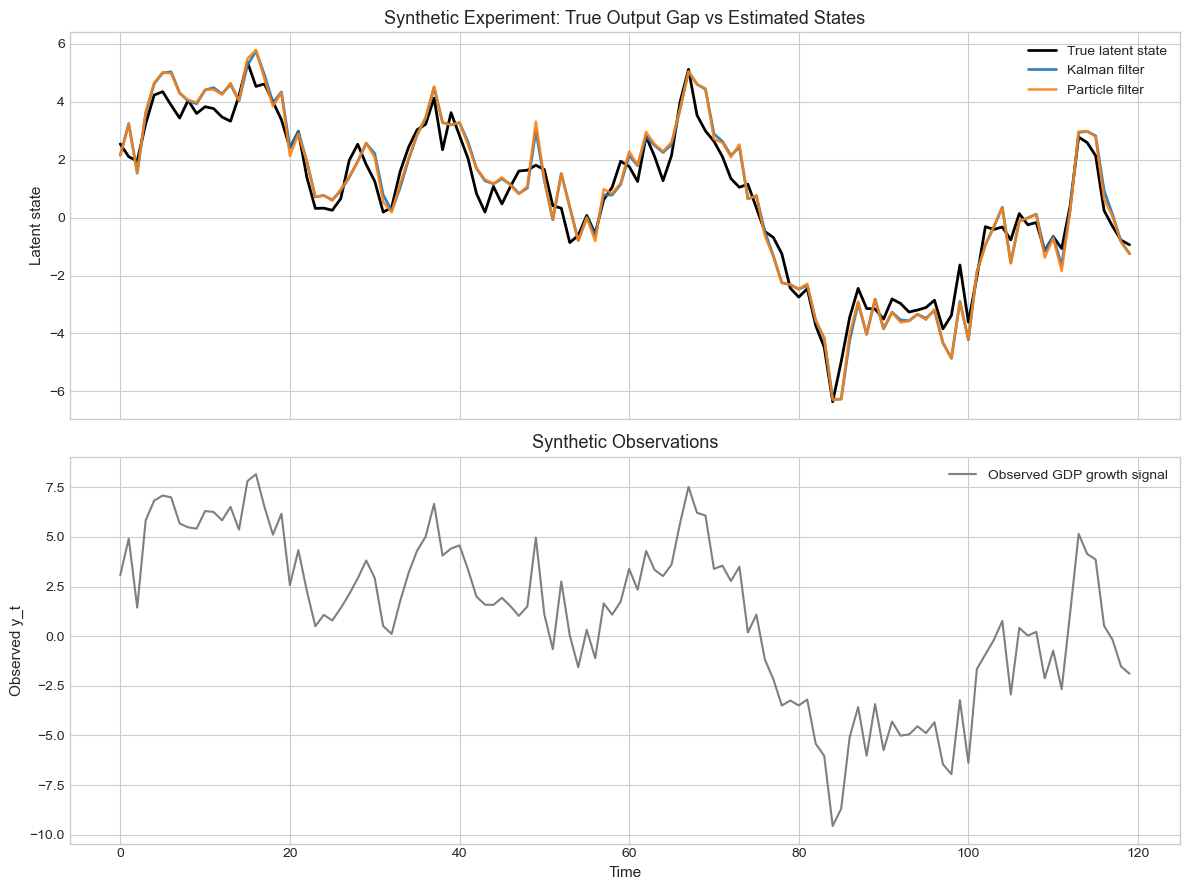

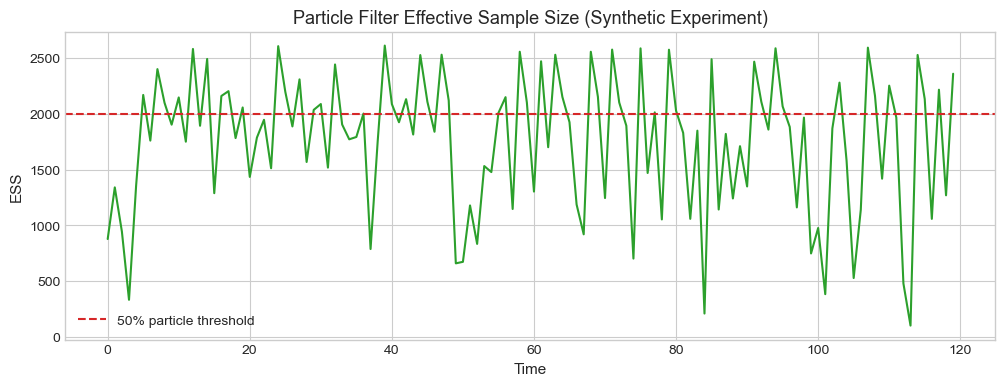

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].plot(x_true, label="True latent state", linewidth=2, color="black")
axes[0].plot(synth_kf["filtered_mean"], label="Kalman filter", linewidth=2, alpha=0.9)
axes[0].plot(synth_pf["filtered_mean"], label="Particle filter", linewidth=1.8, alpha=0.9)
axes[0].set_title("Synthetic Experiment: True Output Gap vs Estimated States")
axes[0].set_ylabel("Latent state")
axes[0].legend()

axes[1].plot(y_synth, label="Observed GDP growth signal", color="tab:gray")
axes[1].set_title("Synthetic Observations")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Observed y_t")
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(synth_pf["ess"], color="tab:green")
plt.axhline(2000, color="tab:red", linestyle="--", label="50% particle threshold")
plt.title("Particle Filter Effective Sample Size (Synthetic Experiment)")
plt.xlabel("Time")
plt.ylabel("ESS")
plt.legend()
plt.show()


### Synthetic Findings

The synthetic experiment is the clean evaluation setting because the true latent state is known.
The key diagnostics are:

- **Parameter recovery**: whether MLE recovers the data-generating `alpha`, `beta`, and `r`.
- **Wald tests**: whether the estimated parameters are statistically distinguishable from the true values.
- **RMSE**: how closely the KF and PF recover the latent output gap.

Because the model is linear and Gaussian, the Kalman filter is the benchmark-optimal estimator. The particle filter should still track the state well, but some efficiency loss relative to the KF is expected due to Monte Carlo noise.


## Real Data: U.S. GDP Growth

The observed series in the CSV is annual GDP growth. To align it with a zero-mean latent output-gap component, I subtract the sample mean and estimate the model on:

\[
y_t^{(centered)} = \text{GDP growth}_t - \overline{\text{GDP growth}}
\]

This is a modeling simplification: the latent state should be interpreted as a cyclical factor driving deviations of GDP growth from its long-run average rather than as a structural output gap estimate from a full macroeconomic model.


In [6]:
y_real = real_df["gdp_growth_centered"].to_numpy()

real_mle = fit_mle(y_real, q=PROJECT_Q)
real_summary = mle_summary(y_real, real_mle, true_params=None, q=PROJECT_Q)
real_kf = real_mle["kf"]
real_pf = particle_filter(
    y_real,
    alpha=real_mle["alpha"],
    beta=real_mle["beta"],
    r=real_mle["r"],
    q=PROJECT_Q,
    n_particles=4000,
    seed=RNG_SEED + 1,
)

real_comparison = pd.DataFrame(
    {
        "correlation_with_kf": [np.corrcoef(real_kf["filtered_mean"], real_pf["filtered_mean"])[0, 1]],
        "mean_abs_difference": [np.mean(np.abs(real_kf["filtered_mean"] - real_pf["filtered_mean"]))],
        "max_abs_difference": [np.max(np.abs(real_kf["filtered_mean"] - real_pf["filtered_mean"]))],
    },
    index=["Particle filter vs KF"],
)

print("Real-data MLE summary")
display(real_summary)
print(f"Maximized log-likelihood: {real_mle['loglik']:.3f}")
print()
print("Agreement between state estimators")
display(real_comparison)


Real-data MLE summary


,estimate,std_error
alpha,0.2208,0.1223
beta,2.0029,0.1793
r,0.0500,0.0000


Maximized log-likelihood: -135.702

Agreement between state estimators


,correlation_with_kf,mean_abs_difference,max_abs_difference
Particle filter vs KF,1.0000,0.0040,0.0388


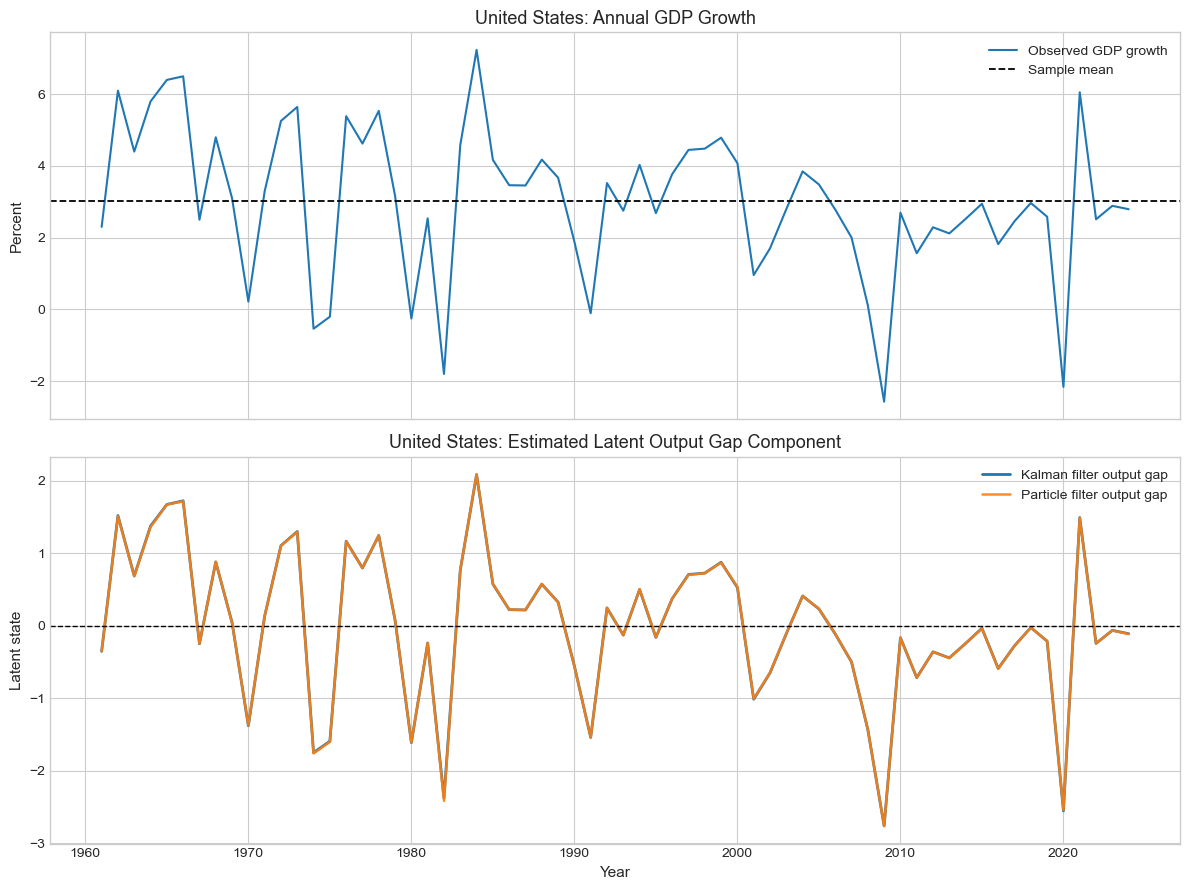

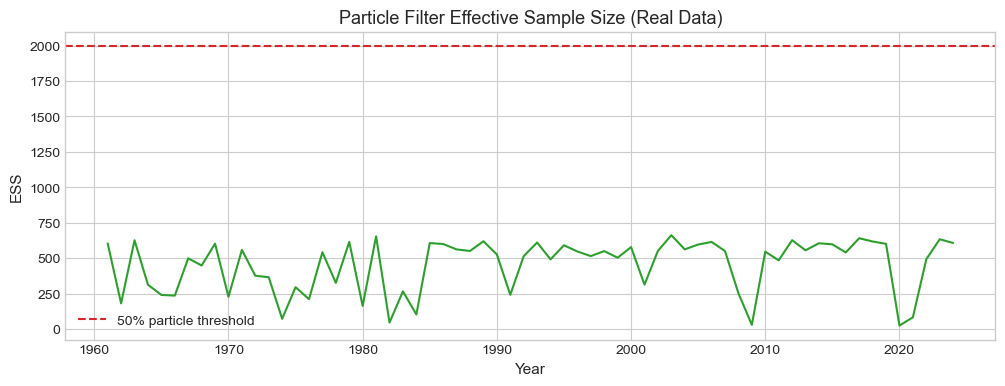

In [7]:
years = real_df["year"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].plot(years, real_df["gdp_growth"], label="Observed GDP growth", color="tab:blue")
axes[0].axhline(real_df["gdp_growth"].mean(), color="black", linestyle="--", linewidth=1.3, label="Sample mean")
axes[0].set_title(f"{country}: Annual GDP Growth")
axes[0].set_ylabel("Percent")
axes[0].legend()

axes[1].plot(years, real_kf["filtered_mean"], label="Kalman filter output gap", linewidth=2)
axes[1].plot(years, real_pf["filtered_mean"], label="Particle filter output gap", linewidth=1.8, alpha=0.9)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"{country}: Estimated Latent Output Gap Component")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Latent state")
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(years, real_pf["ess"], color="tab:green")
plt.axhline(2000, color="tab:red", linestyle="--", label="50% particle threshold")
plt.title("Particle Filter Effective Sample Size (Real Data)")
plt.xlabel("Year")
plt.ylabel("ESS")
plt.legend()
plt.show()


In [8]:
output_gap_table = real_df[["year", "gdp_growth"]].copy()
output_gap_table["kf_output_gap"] = real_kf["filtered_mean"]
output_gap_table["pf_output_gap"] = real_pf["filtered_mean"]
output_gap_table["kf_pf_diff"] = output_gap_table["kf_output_gap"] - output_gap_table["pf_output_gap"]

print("Recent years")
display(output_gap_table.tail(10))


Recent years


,year,gdp_growth,kf_output_gap,pf_output_gap,kf_pf_diff
54,2015,2.9456,-0.0352,-0.0391,0.0039
55,2016,1.8195,-0.5900,-0.5939,0.0039
56,2017,2.4576,-0.2768,-0.2777,0.0009
57,2018,2.9665,-0.0250,-0.0256,0.0006
58,2019,2.5838,-0.2130,-0.2119,-0.0011
59,2020,-2.1630,-2.5544,-2.5419,-0.0125
60,2021,6.0551,1.4919,1.4889,0.0030
61,2022,2.5124,-0.2441,-0.2434,-0.0007
62,2023,2.8876,-0.0638,-0.0661,0.0022
63,2024,2.7930,-0.1100,-0.1144,0.0044


## Discussion and Conclusion

### What changed across methods?

- In the **synthetic setting**, both filters recover the latent state well, but the Kalman filter should usually have the lower RMSE because the assumed model is exactly linear and Gaussian.
- The **particle filter** remains competitive and demonstrates how sequential Monte Carlo can estimate the latent output gap without relying on closed-form Gaussian updating.
- **MLE** is used here for parameter estimation, while KF and PF are used for state estimation. This division is the most coherent way to compare the requested methods in this model.

### Main practical interpretation

For the U.S. GDP-growth application, positive latent-state estimates correspond to periods when growth is above the long-run mean, while negative estimates correspond to below-trend years. The results are therefore best interpreted as a **latent cyclical growth factor / output-gap proxy**, not as an official policy output-gap series.

### Limitations

- The real-data section uses a single observed series, so the latent-state scale must be normalized.
- GDP growth is only a proxy for the output gap; a richer macro model would include inflation, unemployment, or actual-vs-potential GDP structure.
- The particle filter is especially useful once the transition or measurement equations become nonlinear or non-Gaussian. In the strictly linear-Gaussian setting, the Kalman filter remains the efficiency benchmark.
